
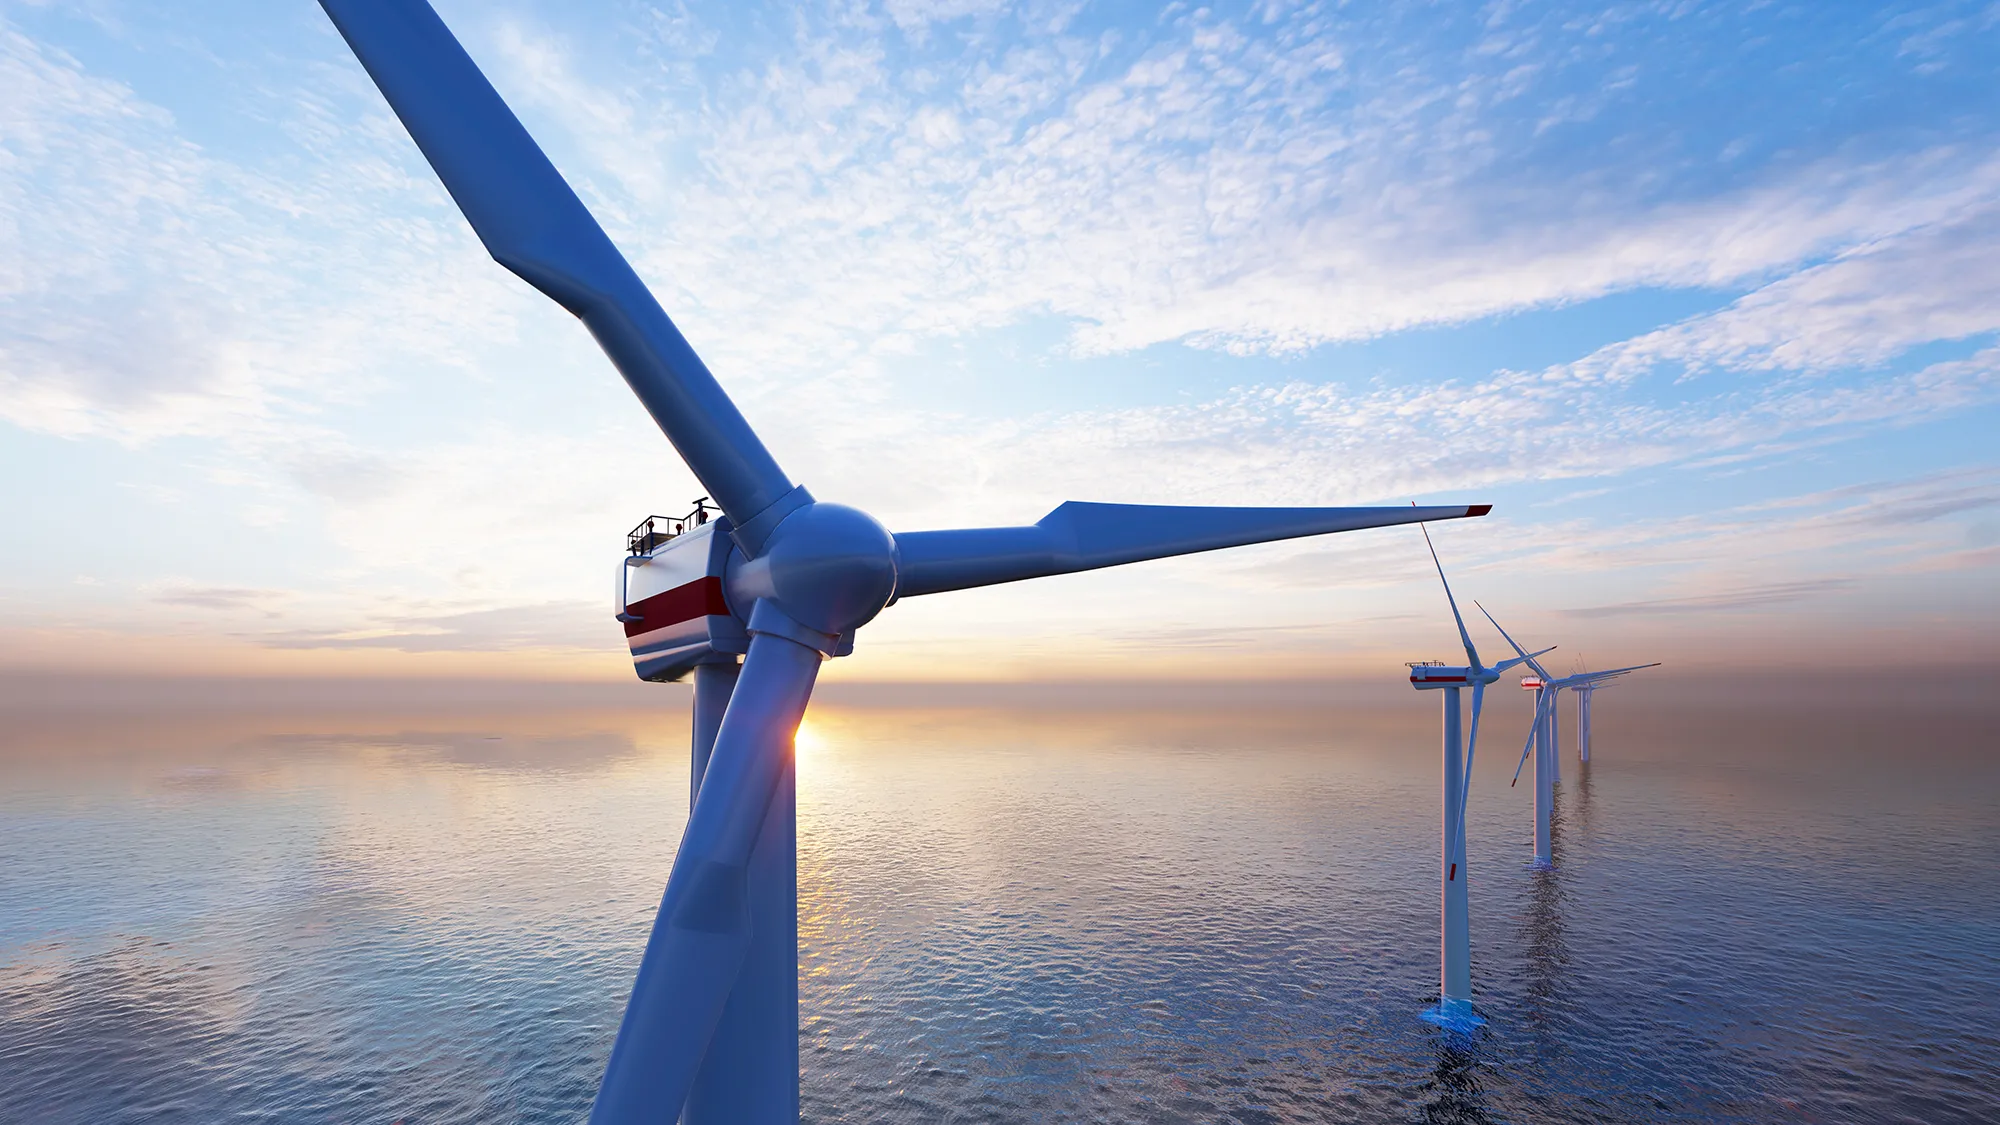

In [ ]:
#@title Project
import requests
from IPython.display import Image, display
from IPython.display import HTML

# Direct image URL
image_url = "https://cdn.prod.website-files.com/5d7b07931e2e7de07043a4e0/659d4e37ad2d55549f39e717_Offshore-wind-farm-supply-chain.webp"

# Download the image
response = requests.get(image_url)
with open('image.jpg', 'wb') as file:
    file.write(response.content)

import base64

# Convert the image to a base64 string
with open("image.jpg", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

# Create the HTML code with the base64 image
html_code = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Portfolio Header</title>
    <!-- Include Font Awesome -->
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.0.0-beta3/css/all.min.css">
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 0;
        }}
        .header {{
            display: flex;
            align-items: flex-start; /* Align items to the top */
            /*align-items: center;*/
            padding: 20px;
            background-color: #f4f4f4;
            border-bottom: 2px solid #ccc;
        }}
        .header img {{
            border-radius: 50%;
            width: 100px;
            height: 100px;
            object-fit: cover;
            margin-right: 20px;
            box-shadow: 0 0 20px #86e3dd; /* Glowing effect */
            vertical-align: top;
        }}
        .header .text-container {{
            display: flex;
            flex-direction: column;
        }}
        .header h1 {{
            margin: 0;
            font-size: 2em;
        }}
        .header p {{
            margin: 5px 0 0 0;
            font-size: 1em;
            color: #666;
        }}
        .header .social-icons {{
            margin-top: 10px;
        }}
        .header .social-icons a {{
            margin-right: 10px;
            color: #666;
            text-decoration: none;
            font-size: 1.5em;
        }}
        .header .social-icons a:hover {{
            color: #000;
        }}
    </style>
</head>
<body>
    <header class="header">
        <img src="data:image/jpeg;base64,{encoded_string}" alt="Profile Picture">
        <div class="text-container">


            <h1>Wind Turbine Performance & Efficiency Analysis - Asset Optimization & Aerodynamic Analysis Project</h1>
            <p>#sql #python #tableau #engineering-analytics</p>
            &nbsp;
            <p>Victory Nwobia</p>

            <div class="social-icons">

                <a href="https://uk.linkedin.com/in/victorynwobia" target="_blank"><i class="fab fa-linkedin"></i></a>
                <a href="mailto:v.nwobia.25@abdn.ac.uk"><i class="fas fa-envelope"></i>


            </div>
        </div>
    </header>
</body>
</html>
"""

# Display the HTML code in the Jupyter/Colab notebook
display(HTML(html_code))

# Introduction

## Stage 1. Project Brief with Management

I work as an R&D Performance Analyst for a clean energy asset management company that operates utility-scale wind farms utilizing advanced composite blade configurations.

Management wants to evaluate operational telemetry data to identify efficiency gaps between real-world power generation and the manufacturer's engineering specifications. High variance or energy drops indicate potential aerodynamic stalls, environmental wake interference, or localized mechanical inefficiencies that dictate where composite structural optimizations are required.

**Goals**:
1. Determine the exact operational windows where the turbine underperforms its theoretical design specifications.
2. Isolate and categorize wind speed regimes to evaluate aerodynamic efficiency.
3. Analyze directional wind patterns to screen for siting errors or wake turbulence effects.

In [ ]:
#@title Step 1. Convert CSV file to an SQL database
import pandas as pd
import os

# Load the uploaded file (Assuming T1.csv is uploaded directly to the environment)
csv_filename = 'T1.csv'

if os.path.exists(csv_filename):
    df = pd.read_csv(csv_filename)
    print("Successfully loaded T1.csv metadata.")
else:
    print("Please ensure T1.csv is uploaded to your current workspace folder!")

# Setup file-based SQLite database
database_filename = 'turbine_analytics.db'
df.to_sql('turbine_data', f'sqlite:///{database_filename}', if_exists='replace', index=False)

# Load SQL magic and connect
%load_ext sql
%sql sqlite:///turbine_analytics.db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

Successfully loaded T1.csv metadata.


In [ ]:
#@title Step 2. SQL — Query the data
# Because column names contain spaces and symbols, we wrap them in backticks
project_data = %sql SELECT `Date/Time`, `LV ActivePower (kW)`, `Wind Speed (m/s)`, `Theoretical_Power_Curve (KWh)`, `Wind Direction (°)` FROM turbine_data

 * sqlite:///turbine_analytics.db
Done.


### Data Description Table
| Variable | Definition | Engineering Value |
| :--- | :--- | :--- |
| **Date/Time** | 10-minute interval timestamps | Time-series trends and seasonal variation |
| **LV ActivePower (kW)** | Actual power output delivered to grid | Real-time performance metric |
| **Wind Speed (m/s)** | Wind velocity recorded by anemometer | Primary input kinetic energy indicator |
| **Theoretical_Power_Curve (KWh)** | Manufacturer's specified power output | Ideal design performance baseline |
| **Wind Direction (°)** | Wind compass heading ($0^\circ - 360^\circ$) | Spatial siting and aerodynamic wake indicator |

In [ ]:
#@title Step 3. Python — Data Imputation & Engineering

# Bring the queried data back into a Pandas environment
df = pd.DataFrame(project_data)

print("--- DataFrame Head ---")
print(df.head(10))

print("\n--- Summary Statistics ---")
print(df.describe())

print("\n--- Missing Values Audit ---")
print(df.isnull().sum())

# Data Cleaning: Address sensor clipping and negative readings
# In real SCADA streams, negative readings indicate sensor errors or internal power consumption during downtime.
df['LV ActivePower (kW)'] = df['LV ActivePower (kW)'].apply(lambda x: 0 if x < 0 else x)

# Feature Engineering: Calculate the absolute Power Loss Gap (Theoretical vs Actual)
df['Power_Loss_kW'] = df['Theoretical_Power_Curve (KWh)'] - df['LV ActivePower (kW)']
df['Power_Loss_kW'] = df['Power_Loss_kW'].round(2)

# Categorize Operational Wind Velocity Regimes (Similar to your Age categorization)
def categorize_wind_regime(speed):
    if speed <= 3.5:
        return 'Below Cut-In (No Power)'
    elif 3.5 < speed <= 12.0:
        return 'Optimal Operational Sweep'
    elif 12.0 < speed <= 25.0:
        return 'Rated Peak / Pitch Control'
    else:
        return 'Cut-Out (Storm Protection)'

# Apply the structural categorization
df['Wind_Regime'] = df['Wind Speed (m/s)'].apply(categorize_wind_regime)

print("\n--- Telemetry Distribution across Wind Regimes ---")
print(df['Wind_Regime'].value_counts())

# Export finalized clean dataset to Excel for Tableau integration
df.to_excel("turbine_performance_output.xlsx", index=False)
print("\nSuccess: Cleaned performance data exported to turbine_performance_output.xlsx")

--- DataFrame Head ---
          Date/Time  LV ActivePower (kW)  Wind Speed (m/s)  \
0  01 01 2018 00:00           380.047791          5.311336   
1  01 01 2018 00:10           453.769196          5.672167   
2  01 01 2018 00:20           306.376587          5.216037   
3  01 01 2018 00:30           419.645905          5.659674   
4  01 01 2018 00:40           380.650696          5.577941   
5  01 01 2018 00:50           402.391998          5.604052   
6  01 01 2018 01:00           447.605713          5.793008   
7  01 01 2018 01:10           387.242188          5.306050   
8  01 01 2018 01:20           463.651215          5.584629   
9  01 01 2018 01:30           439.725708          5.523228   

   Theoretical_Power_Curve (KWh)  Wind Direction (°)  
0                     416.328908          259.994904  
1                     519.917511          268.641113  
2                     390.900016          272.564789  
3                     516.127569          271.258087  
4                  

In [1]:
#@title Tableau Dashboard Integration
from IPython.display import HTML

# Leave your Tableau public link template ready to receive your upcoming visual
HTML("""
<div class='tableauPlaceholder' id='viz1779293919486' style='position: relative'><noscript><a href='#'><img alt='North Sea -  Wind Turbine Performance &amp; Efficiency Analysis ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Wi&#47;WindTurbinePerformanceEfficiencyAnalysis-AssetOptimizationAerodynamicAnalysisProject&#47;Dashboard1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='WindTurbinePerformanceEfficiencyAnalysis-AssetOptimizationAerodynamicAnalysisProject&#47;Dashboard1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Wi&#47;WindTurbinePerformanceEfficiencyAnalysis-AssetOptimizationAerodynamicAnalysisProject&#47;Dashboard1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1779293919486');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1024px';vizElement.style.height='795px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1024px';vizElement.style.height='795px';} else { vizElement.style.width='100%';vizElement.style.height='1327px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>
""")

[Link Tableau](https://public.tableau.com/views/WindTurbinePerformanceEfficiencyAnalysis-AssetOptimizationAerodynamicAnalysisProject/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)


**Goal**: Compare actual turbine power generation against the manufacturer's design curve to locate performance gaps.

**Assessment**: By Wind Speed: The turbine suffers its highest average power deficit (242.3 kW) during mid-range speeds (3.5 to 12 m/s), indicating the blades lose aerodynamic efficiency before hitting full capacity.

By Wind Direction: Power losses spike over 328 kW when the wind blows from the North-Northeast (20° to 30° headings), proving severe wake turbulence or structural interference from that specific direction.

By Season: Energy loss peaks in January with the turbine missing its design target by 28.4%, while performance peaks in March with a minimal 5.9% deficit.

**Recommendations**:

	•	Clean the blades or install aerodynamic upgrades to fix the 242.3 kW mid-range efficiency drop.
	•	Adjust blade pitch control software when facing the 20° to 30° corridor to reduce turbulence wear.
	•	Schedule routine maintenance and composite inspections during low-wind summer months to protect winter revenue.